In [2]:
# Import required libraries
import sys
sys.path.append('..')

import numpy as np
import librosa
import os

# Import matplotlib pyplot directly
from matplotlib import pyplot as plt
%matplotlib inline

from src.extractor import AudioExtractor, midi_number_to_note_name
from src import utils

# print(f"librosa version: {librosa.__version__}")
print("Imports successful!")

Imports successful!


## 1. Generate Test Audio

Create a synthetic melody to test pitch detection accuracy.

In [3]:
# Generate test melody: C major scale
sr = 22050
duration = 0.5  # seconds per note

# MIDI notes for C major scale
midi_notes = [60, 62, 64, 65, 67, 69, 71, 72]  # C4 to C5
frequencies = [librosa.midi_to_hz(m) for m in midi_notes]

# Generate sine waves
audio = np.array([])
for freq in frequencies:
    t = np.linspace(0, duration, int(sr * duration))
    note = 0.5 * np.sin(2 * np.pi * freq * t)
    # Add fade in/out
    fade_len = int(sr * 0.05)
    note[:fade_len] *= np.linspace(0, 1, fade_len)
    note[-fade_len:] *= np.linspace(1, 0, fade_len)
    audio = np.concatenate([audio, note])

print(f"Generated {len(audio)} samples ({len(audio)/sr:.2f} seconds)")
print(f"Notes: {[midi_number_to_note_name(m) for m in midi_notes]}")

Generated 88200 samples (4.00 seconds)
Notes: ['C4', 'D4', 'E4', 'F4', 'G4', 'A4', 'B4', 'C5']


## 2. Visualize Audio Waveform

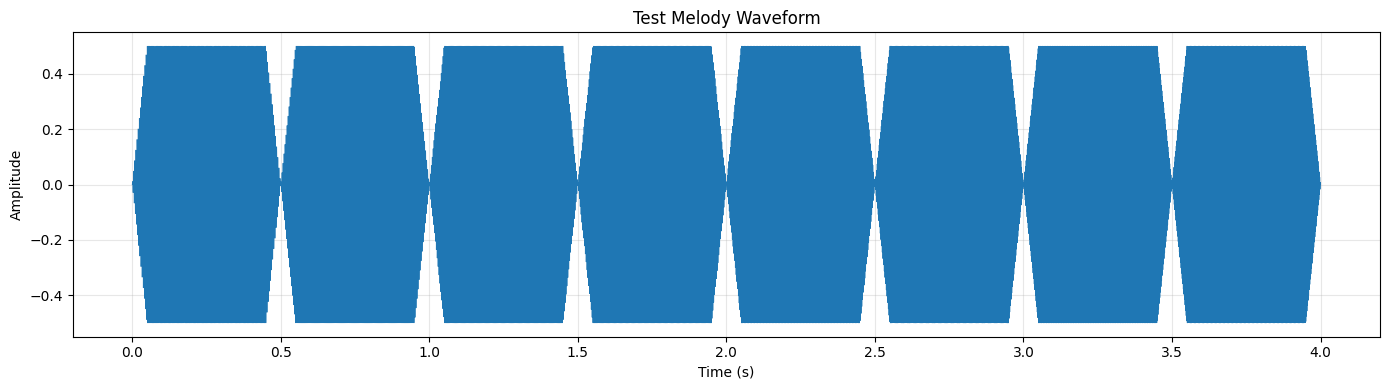

In [4]:
# Plot waveform manually to avoid matplotlib state issues
time_axis = np.linspace(0, len(audio) / sr, len(audio))

plt.figure(figsize=(14, 4))
plt.plot(time_axis, audio, linewidth=0.5)
plt.title('Test Melody Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Compute Spectrogram

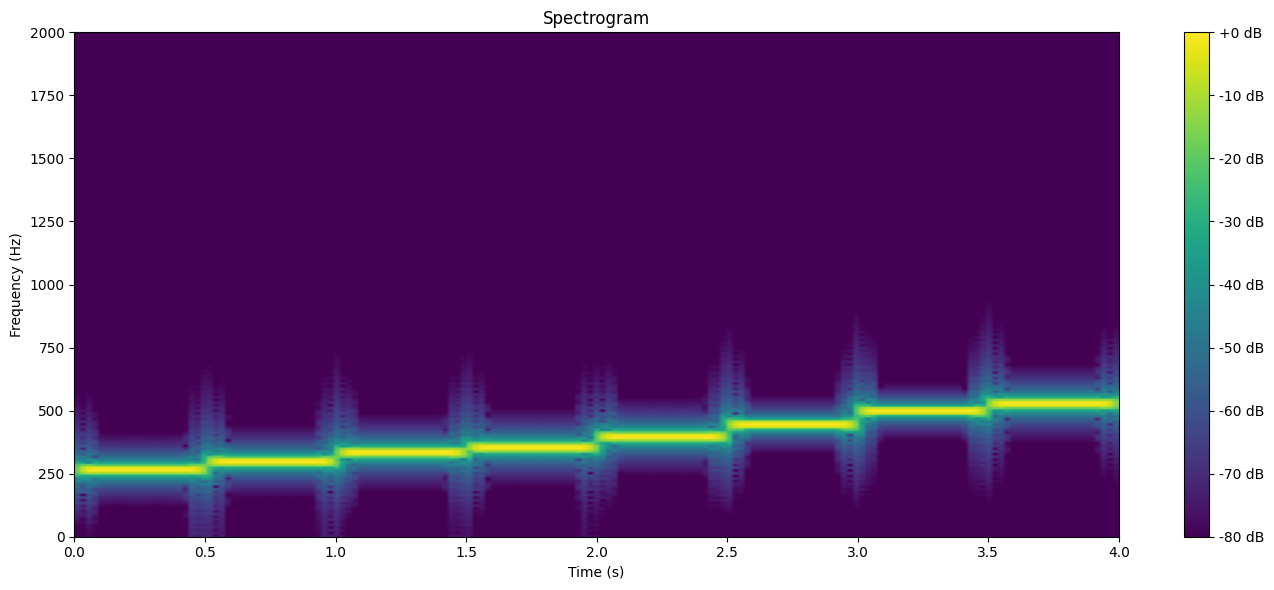

In [7]:
# Compute Short-Time Fourier Transform
D = librosa.stft(audio)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Plot spectrogram manually to avoid librosa.display compatibility issues
fig, ax = plt.subplots(figsize=(14, 6))
img = ax.imshow(S_db, aspect='auto', origin='lower', cmap='viridis', 
                extent=[0, len(audio)/sr, 0, sr/2])
plt.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title('Spectrogram')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim([0, 2000])  # Focus on relevant frequency range
plt.tight_layout()
plt.show()

## 4. Test pYIN Pitch Detection

In [8]:
# Save test audio
import soundfile as sf
test_path = '../data/raw/test_scale.wav'
sf.write(test_path, audio, sr)

# Extract with pYIN
extractor_pyin = AudioExtractor(method='pyin', min_note_duration=0.1)
notes_pyin = extractor_pyin.extract(test_path)

print(f"\nDetected {len(notes_pyin)} notes:")
for i, note in enumerate(notes_pyin):
    note_name = midi_number_to_note_name(note.midi_number)
    print(f"{i+1}. {note_name} (MIDI {note.midi_number}) - {note.onset:.2f}s to {note.offset:.2f}s")

Extracting MIDI with pYIN...
Loading audio: ../data/raw/test_scale.wav
Extracted 8 notes

Detected 8 notes:
1. C4 (MIDI 60) - 0.02s to 0.53s
2. D4 (MIDI 62) - 0.53s to 1.02s
3. E4 (MIDI 64) - 1.04s to 1.53s
4. F4 (MIDI 65) - 1.53s to 2.02s
5. G4 (MIDI 67) - 2.04s to 2.53s
6. A4 (MIDI 69) - 2.53s to 3.02s
7. B4 (MIDI 71) - 3.04s to 3.53s
8. C5 (MIDI 72) - 3.53s to 4.02s


## 5. Visualize Detected Pitches

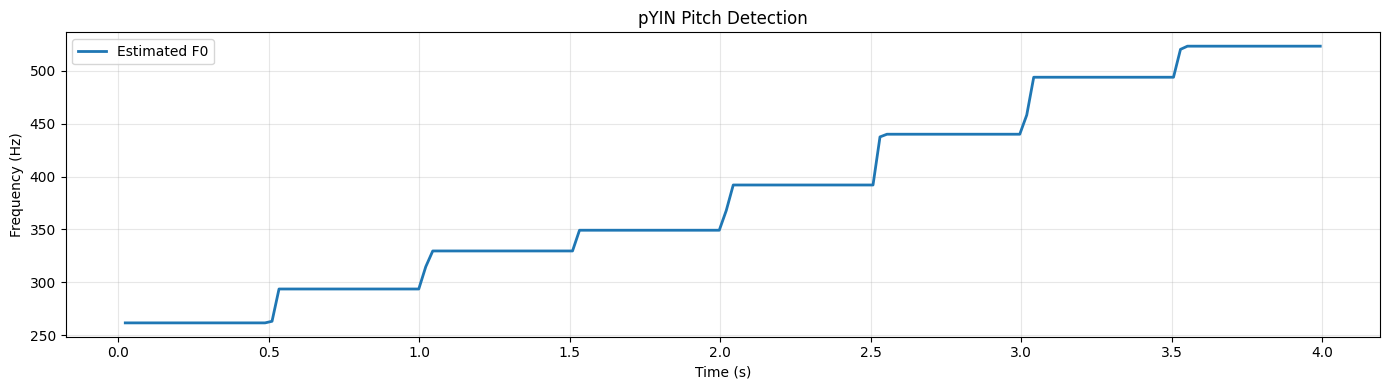

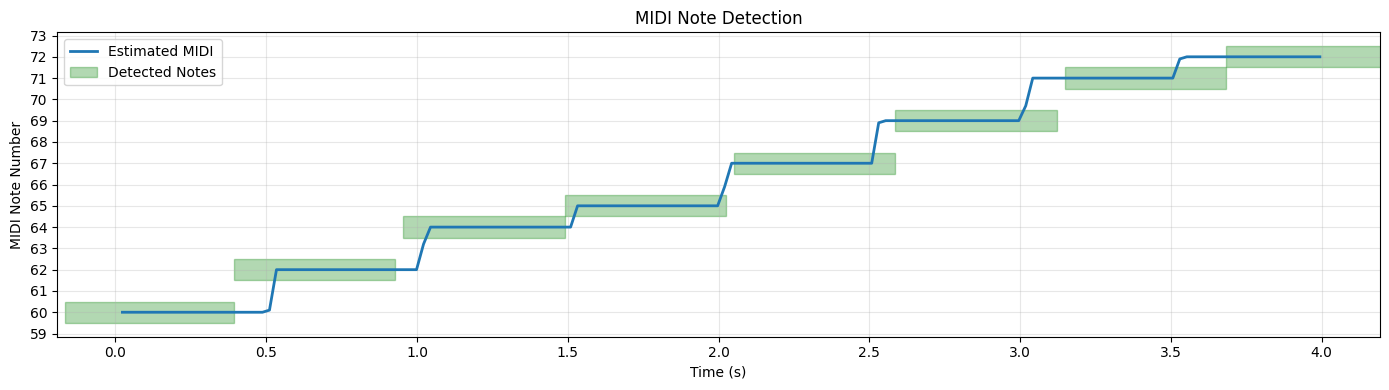

In [9]:
# Extract raw F0 for visualization
f0, voiced_flag, voiced_probs = librosa.pyin(
    audio,
    fmin=librosa.note_to_hz('C2'),
    fmax=librosa.note_to_hz('C6'),
    sr=sr
)

# Convert to MIDI
f0_midi = librosa.hz_to_midi(f0)

# Create time array
times = librosa.times_like(f0, sr=sr)

# Plot 1: F0 in Hz
plt.figure(figsize=(14, 4))
plt.plot(times, f0, linewidth=2, label='Estimated F0')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('pYIN Pitch Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: MIDI notes with detected note overlays
plt.figure(figsize=(14, 4))
plt.plot(times, f0_midi, linewidth=2, label='Estimated MIDI')
# Overlay detected notes
for i, note in enumerate(notes_pyin):
    plt.axhspan(note.midi_number - 0.5, note.midi_number + 0.5,
                xmin=note.onset/times[-1], xmax=note.offset/times[-1],
                alpha=0.3, color='green', label='Detected Notes' if i == 0 else '')
plt.xlabel('Time (s)')
plt.ylabel('MIDI Note Number')
plt.title('MIDI Note Detection')
plt.yticks(range(59, 74))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Accuracy Evaluation

In [10]:
# Compare detected notes with ground truth
ground_truth = midi_notes
detected = [n.midi_number for n in notes_pyin]

print("Accuracy Evaluation:")
print("=" * 60)
print(f"Ground truth notes: {len(ground_truth)}")
print(f"Detected notes:     {len(detected)}")

# Calculate accuracy
if len(detected) == len(ground_truth):
    correct = sum(1 for d, g in zip(detected, ground_truth) if d == g)
    accuracy = correct / len(ground_truth) * 100
    print(f"Correct notes:      {correct}/{len(ground_truth)}")
    print(f"Accuracy:           {accuracy:.1f}%")
    
    # Show errors
    print("\nDetailed comparison:")
    for i, (g, d) in enumerate(zip(ground_truth, detected)):
        status = "✓" if g == d else "✗"
        g_name = midi_number_to_note_name(g)
        d_name = midi_number_to_note_name(d)
        print(f"{status} Note {i+1}: Expected {g_name} (MIDI {g}), Got {d_name} (MIDI {d})")
else:
    print("WARNING: Number of detected notes doesn't match ground truth!")
    print(f"Expected: {[midi_number_to_note_name(m) for m in ground_truth]}")
    print(f"Detected: {[midi_number_to_note_name(m) for m in detected]}")

Accuracy Evaluation:
Ground truth notes: 8
Detected notes:     8
Correct notes:      8/8
Accuracy:           100.0%

Detailed comparison:
✓ Note 1: Expected C4 (MIDI 60), Got C4 (MIDI 60)
✓ Note 2: Expected D4 (MIDI 62), Got D4 (MIDI 62)
✓ Note 3: Expected E4 (MIDI 64), Got E4 (MIDI 64)
✓ Note 4: Expected F4 (MIDI 65), Got F4 (MIDI 65)
✓ Note 5: Expected G4 (MIDI 67), Got G4 (MIDI 67)
✓ Note 6: Expected A4 (MIDI 69), Got A4 (MIDI 69)
✓ Note 7: Expected B4 (MIDI 71), Got B4 (MIDI 71)
✓ Note 8: Expected C5 (MIDI 72), Got C5 (MIDI 72)


## 7. Test with Real Audio (Optional)

If you have a real vocal recording, test it here.

In [11]:
# Uncomment and modify path to test with real audio
real_audio_path = '../data/raw/test.mp3'

if os.path.exists(real_audio_path):
    # Analyze pitch range
    pitch_info = utils.analyze_pitch_range(real_audio_path)
    print("Pitch Analysis:")
    for key, value in pitch_info.items():
        print(f"  {key}: {value}")
    
    # Extract notes
    notes = extractor_pyin.extract(real_audio_path)
    print(f"\nExtracted {len(notes)} notes")
else:
    print(f"Audio file not found: {real_audio_path}")

# print("Uncomment the code above to test with real audio")

Pitch Analysis:
  min_freq: 70.10083450255941
  max_freq: 353.2860680198856
  mean_freq: 237.70100793072513
  min_midi: 37
  max_midi: 65
  min_note: C#2
  max_note: F4
  range_semitones: 28
Extracting MIDI with pYIN...
Loading audio: ../data/raw/test.mp3
Extracted 35 notes

Extracted 35 notes


## Summary

This notebook demonstrated:
1. Generating synthetic test audio
2. Visualizing waveforms and spectrograms
3. Testing pYIN pitch detection
4. Evaluating accuracy against ground truth

**Next Steps:**
- Try with real vocal recordings
- Test Basic Pitch method for comparison
- Tune parameters for better accuracy